# Global Cultural & Multilingual Lyric Analysis
### Cross-Lingual Semantic Space, Emotional Patterns, Lexical Diversity, and Thematic Clusters Across 10,000 Songs

This notebook explores the rich **multilingual NLP descriptors** and **deep neural embeddings** included in the Spotify 10k dataset. We analyze lyric storytelling patterns across **35 language/script categories** (including English, Spanish, Hindi Devanagari & Romanized Hinglish, Korean, Japanese, Portuguese, Indonesian, Turkish, French, etc.) using:

- **Microsoft Harrier-OSS-v1-0.6B (1024-D):** 32k context multilingual decoder embeddings.
- **Multilingual E5-Large (1024-D):** Dense contrastive sentence representations.
- **Language ID & Script Flags (`language_id.parquet`):** 34 primary/secondary language and script indicators.
- **Lexical Statistics (`lyric_stats.parquet`):** TTR, Root-TTR, MTLD, Hapax ratio, VADER sentiment, and NRC EmoLex.
- **GoEmotions (`go_emotions.parquet`):** 28 fine-grained RoBERTa emotion probability scores.
- **BERTopic (`bertopic_topics.parquet`):** 32 discovered thematic lyric clusters.


## 1. Setup & Data Loading

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Robust path resolution for Local Repo or Kaggle environment
if Path('data/metadata/songs.parquet').exists():
    DATA_DIR = Path('data')
elif Path('../data/metadata/songs.parquet').exists():
    DATA_DIR = Path('../data')
elif Path('/kaggle/input/spotify-10k-music-features').exists():
    DATA_DIR = Path('/kaggle/input/spotify-10k-music-features')
else:
    raise FileNotFoundError("Dataset path not found.")

songs = pd.read_parquet(DATA_DIR / 'metadata' / 'songs.parquet')
lang_df = pd.read_parquet(DATA_DIR / 'features' / 'lyric' / 'language_id.parquet')
lyric_stats = pd.read_parquet(DATA_DIR / 'features' / 'lyric' / 'lyric_stats.parquet')
emotions = pd.read_parquet(DATA_DIR / 'features' / 'lyric' / 'go_emotions.parquet')
topics = pd.read_parquet(DATA_DIR / 'features' / 'lyric' / 'bertopic_topics.parquet')

# Load deep lyric embeddings
harrier = np.load(DATA_DIR / 'embeddings' / 'lyric' / 'harrier_embeddings_1024d.npy')

with open(DATA_DIR / 'features' / 'lyric' / 'bertopic_topic_labels.json') as f:
    topic_labels = json.load(f)

print(f"Loaded {len(songs):,} songs with multilingual annotations.")


Loaded 10,000 songs with multilingual annotations.


## 2. Global Music Language & Script Distribution
We inspect the distribution across major global music markets, highlighting both native scripts and Romanized variants (such as Latin-script Hinglish).


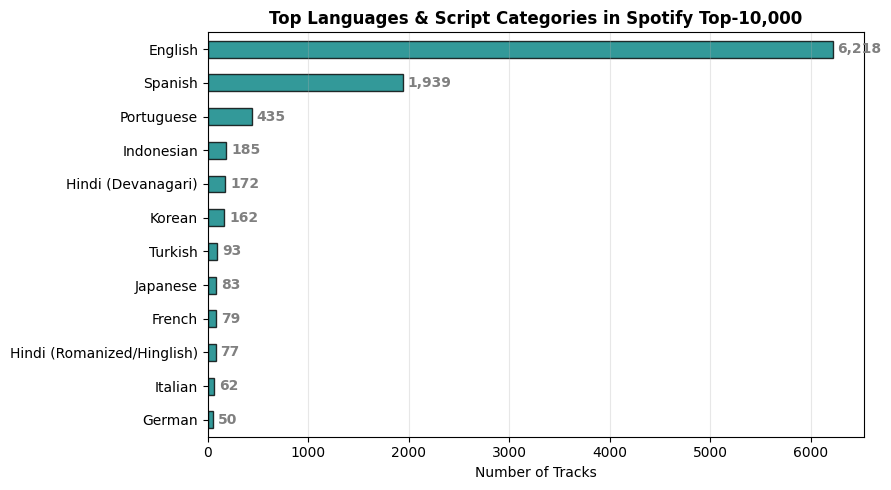

In [2]:
# Summarize key language counts
lang_counts = {
    'English': lang_df['is_english'].sum(),
    'Spanish': lang_df['is_spanish'].sum(),
    'Portuguese': lang_df['is_portuguese'].sum(),
    'Hindi (Devanagari)': lang_df['is_hindi_devanagari'].sum(),
    'Hindi (Romanized/Hinglish)': lang_df['is_hindi_romanized'].sum(),
    'Indonesian': lang_df['is_indonesian'].sum(),
    'Korean': lang_df['is_korean'].sum(),
    'Turkish': lang_df['is_turkish'].sum(),
    'Japanese': lang_df['is_japanese'].sum(),
    'French': lang_df['is_french'].sum(),
    'Italian': lang_df['is_italian'].sum(),
    'German': lang_df['is_german'].sum()
}

s_lang = pd.Series(lang_counts).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
s_lang.plot(kind='barh', color='teal', edgecolor='black', alpha=0.8)
plt.title("Top Languages & Script Categories in Spotify Top-10,000", fontsize=12, fontweight='bold')
for i, v in enumerate(s_lang):
    plt.text(v + 50, i, f"{v:,}", va='center', fontsize=10, fontweight='bold', color='gray')
plt.xlabel("Number of Tracks")
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 3. High-Resolution 2D Semantic Lyric Space (`umap_2d_lyric.parquet`)
We visualize the **2D UMAP projection** of the fused `Harrier-0.6B + Multilingual E5-Large` representation, colored across global languages with dedicated cluster callouts.


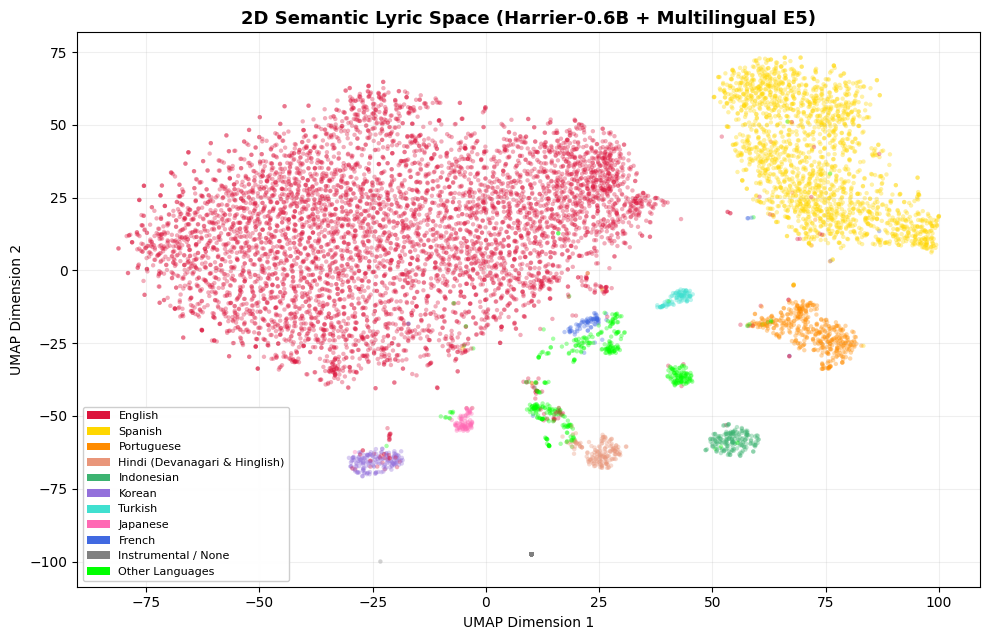

In [3]:
umap_lyric = pd.read_parquet(DATA_DIR / 'similarity' / 'umap_2d_lyric.parquet')

plt.figure(figsize=(10, 6.5))

# Map known languages, then fill unknowns with 'lime'
colors = lang_df['primary_language'].map({
    'en': 'crimson',
    'es': 'gold',
    'pt': 'darkorange',
    'hi': 'darksalmon',
    'id': 'mediumseagreen',
    'ko': 'mediumpurple',
    'tr': 'turquoise',
    'ja': 'hotpink',
    'fr': 'royalblue',
    'none': 'gray'
}).fillna('lime')

plt.scatter(
    umap_lyric['proj_x'], 
    umap_lyric['proj_y'],
    c=colors,
    alpha=0.35, 
    s=10,
    edgecolors='none'
)

plt.title("2D Semantic Lyric Space (Harrier-0.6B + Multilingual E5)", fontsize=13, fontweight='bold')
plt.xlabel("UMAP Dimension 1", fontsize=10)
plt.ylabel("UMAP Dimension 2", fontsize=10)
plt.grid(True, alpha=0.2)

# Rich legend with colored patches
legend_elements = [
    Patch(facecolor='crimson', label='English'),
    Patch(facecolor='gold', label='Spanish'),
    Patch(facecolor='darkorange', label='Portuguese'),
    Patch(facecolor='darksalmon', label='Hindi (Devanagari & Hinglish)'),
    Patch(facecolor='mediumseagreen', label='Indonesian'),
    Patch(facecolor='mediumpurple', label='Korean'),
    Patch(facecolor='turquoise', label='Turkish'),
    Patch(facecolor='hotpink', label='Japanese'),
    Patch(facecolor='royalblue', label='French'),
    Patch(facecolor='gray', label='Instrumental / None'),
    Patch(facecolor='lime', label='Other Languages')
]
plt.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.95)

plt.tight_layout()
plt.show()


## 4. Cross-Lingual Semantic Similarity Geometry
Using the normalized **Harrier-0.6B (1024-D)** embeddings, we compute the average pairwise cosine similarity between different global language corpora to see which languages cluster closest in narrative style.


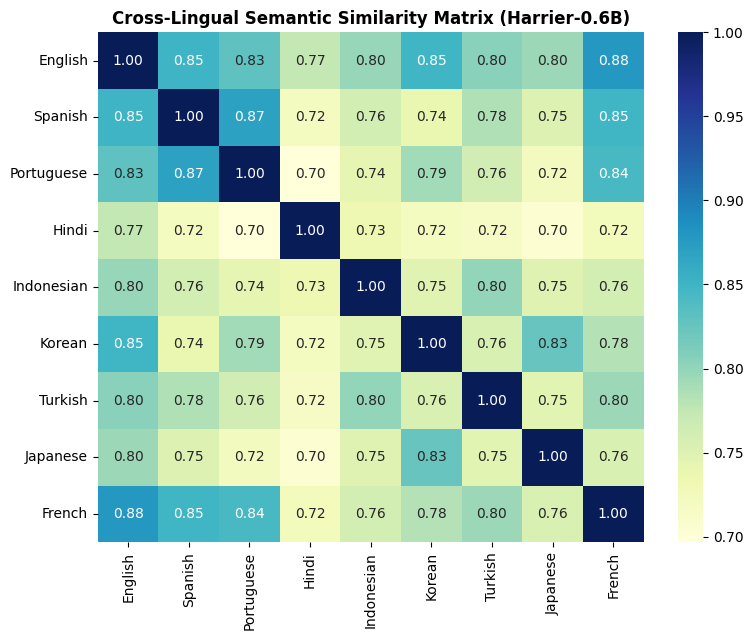

In [4]:
# Compute language centroids using Harrier embeddings
top_langs_eval = ['en', 'es', 'pt', 'hi', 'id', 'ko', 'tr', 'ja', 'fr']
lang_labels = {
    'en': 'English', 'es': 'Spanish', 'pt': 'Portuguese', 'hi': 'Hindi',
    'id': 'Indonesian', 'ko': 'Korean', 'tr': 'Turkish', 'ja': 'Japanese', 'fr': 'French'
}

# L2 Normalize Harrier vectors
harrier_norm = harrier / np.maximum(np.linalg.norm(harrier, axis=1, keepdims=True), 1e-8)

centroids = {}
for lang in top_langs_eval:
    mask = (lang_df['primary_language'] == lang) & np.any(harrier != 0, axis=1)
    if mask.sum() > 0:
        c = harrier_norm[mask].mean(axis=0)
        centroids[lang_labels[lang]] = c / np.linalg.norm(c)

df_centroids = pd.DataFrame(centroids)
sim_matrix = df_centroids.T @ df_centroids

plt.figure(figsize=(8, 6.5))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Cross-Lingual Semantic Similarity Matrix (Harrier-0.6B)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Lexical Diversity & Vocabulary Richness Across Languages
We analyze **Type-Token Ratio (TTR)**, **Measure of Textual Lexical Diversity (MTLD)**, and **Hapax Legomena Ratio** (ratio of unique single-use words).


In [5]:
df_lex = pd.DataFrame({
    'language': lang_df['primary_language'].map(lang_labels),
    'ttr': lyric_stats['ttr'],
    'root_ttr': lyric_stats['root_ttr'],
    'mtld': lyric_stats['mtld'],
    'hapax_ratio': lyric_stats['hapax_ratio'],
    'line_count': lyric_stats['line_count']
})

df_lex_filtered = df_lex[df_lex['language'].notna() & (df_lex['line_count'] > 5)]

# print explanatory text about columns and what they mean in terms of lexical diversity, e.g., TTR, MTLD, Hapax Legomena ratio, etc.
print("\nLexical Diversity Metrics Explained:")
print("1. TTR (Type-Token Ratio): Measures the ratio of unique words (types) to total words (tokens). Higher values indicate greater lexical diversity.")
print("2. Root TTR: A variation of TTR that accounts for text length, providing a more stable measure of lexical diversity across different text sizes.")
print("3. MTLD (Measure of Textual Lexical Diversity): A measure of lexical diversity that is less sensitive to text length than TTR.")
print("4. Hapax Legomena Ratio: The ratio of words that appear only once in the text to the total number of words in the text.")

lex_summary = df_lex_filtered.groupby('language')[['ttr', 'root_ttr', 'mtld', 'hapax_ratio']].median()
print("\nMedian Lexical Diversity by Language:")
lex_summary.sort_values(by='ttr', ascending=False)



Lexical Diversity Metrics Explained:
1. TTR (Type-Token Ratio): Measures the ratio of unique words (types) to total words (tokens). Higher values indicate greater lexical diversity.
2. Root TTR: A variation of TTR that accounts for text length, providing a more stable measure of lexical diversity across different text sizes.
3. MTLD (Measure of Textual Lexical Diversity): A measure of lexical diversity that is less sensitive to text length than TTR.
4. Hapax Legomena Ratio: The ratio of words that appear only once in the text to the total number of words in the text.

Median Lexical Diversity by Language:


,ttr,root_ttr,mtld,hapax_ratio
language,,,,
Japanese,0.68000,5.83460,46.910,0.52380
Turkish,0.45610,6.05900,47.120,0.26830
Korean,0.44105,7.50045,37.660,0.27260
Indonesian,0.42170,5.25070,44.330,0.19570
Spanish,0.39640,6.91100,54.170,0.20740
Hindi,0.36360,5.50000,24.130,0.19530
French,0.32650,6.64720,33.090,0.17460
English,0.32440,5.90145,31.605,0.16375
Portuguese,0.28900,4.84070,41.650,0.07800


## 6. Emotional Profiles Across Genres (NRC & GoEmotions)
We examine the dominant emotional nuances (Joy, Sadness, Anger, Anticipation, Fear) across musical genres.


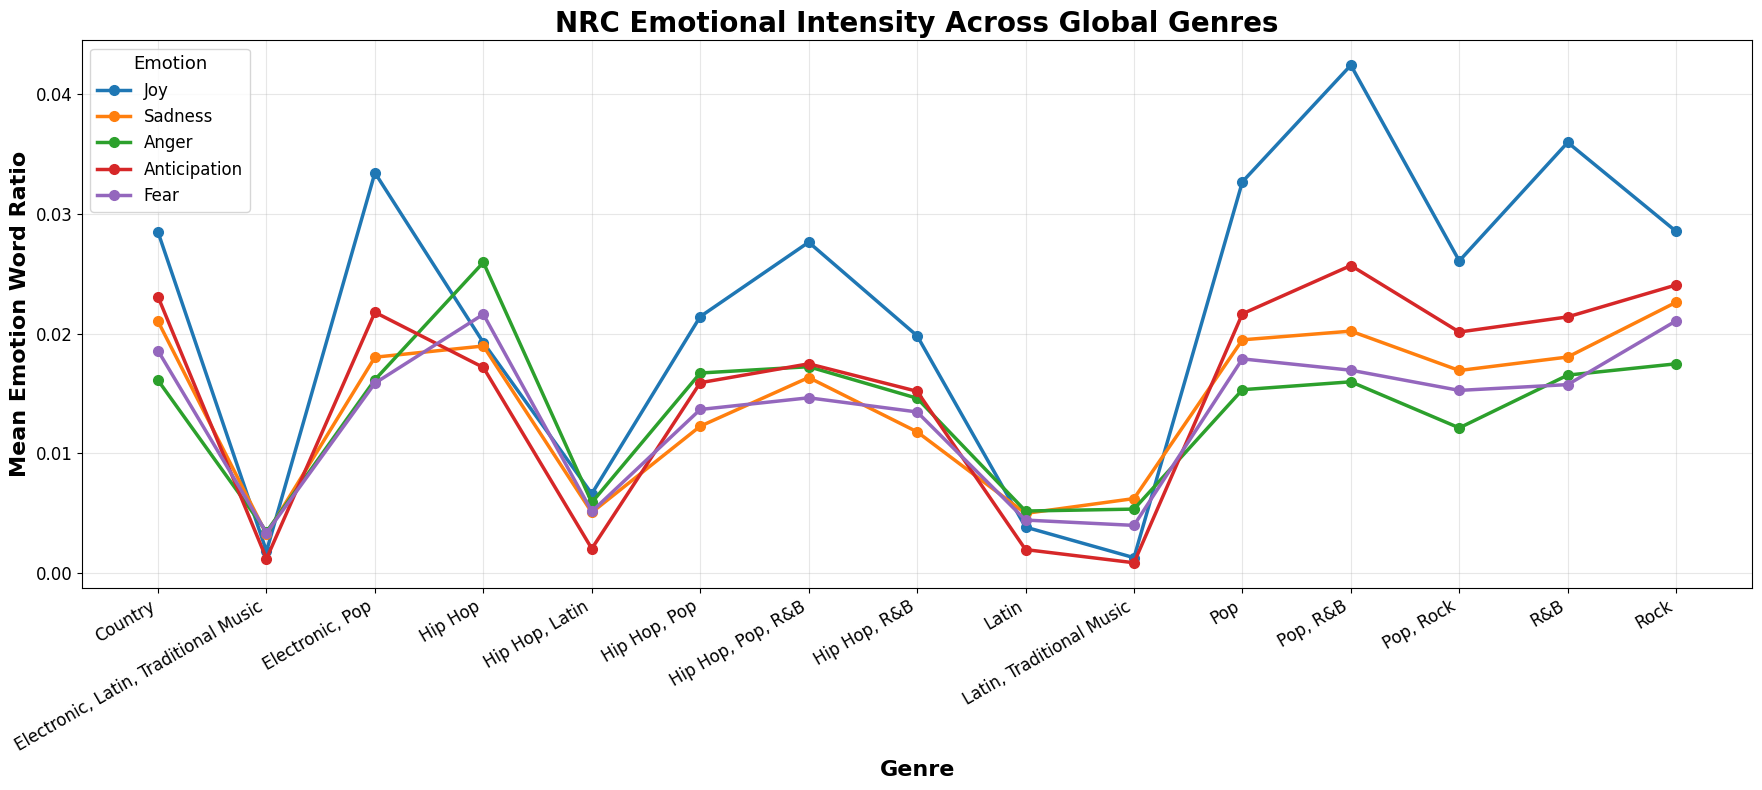

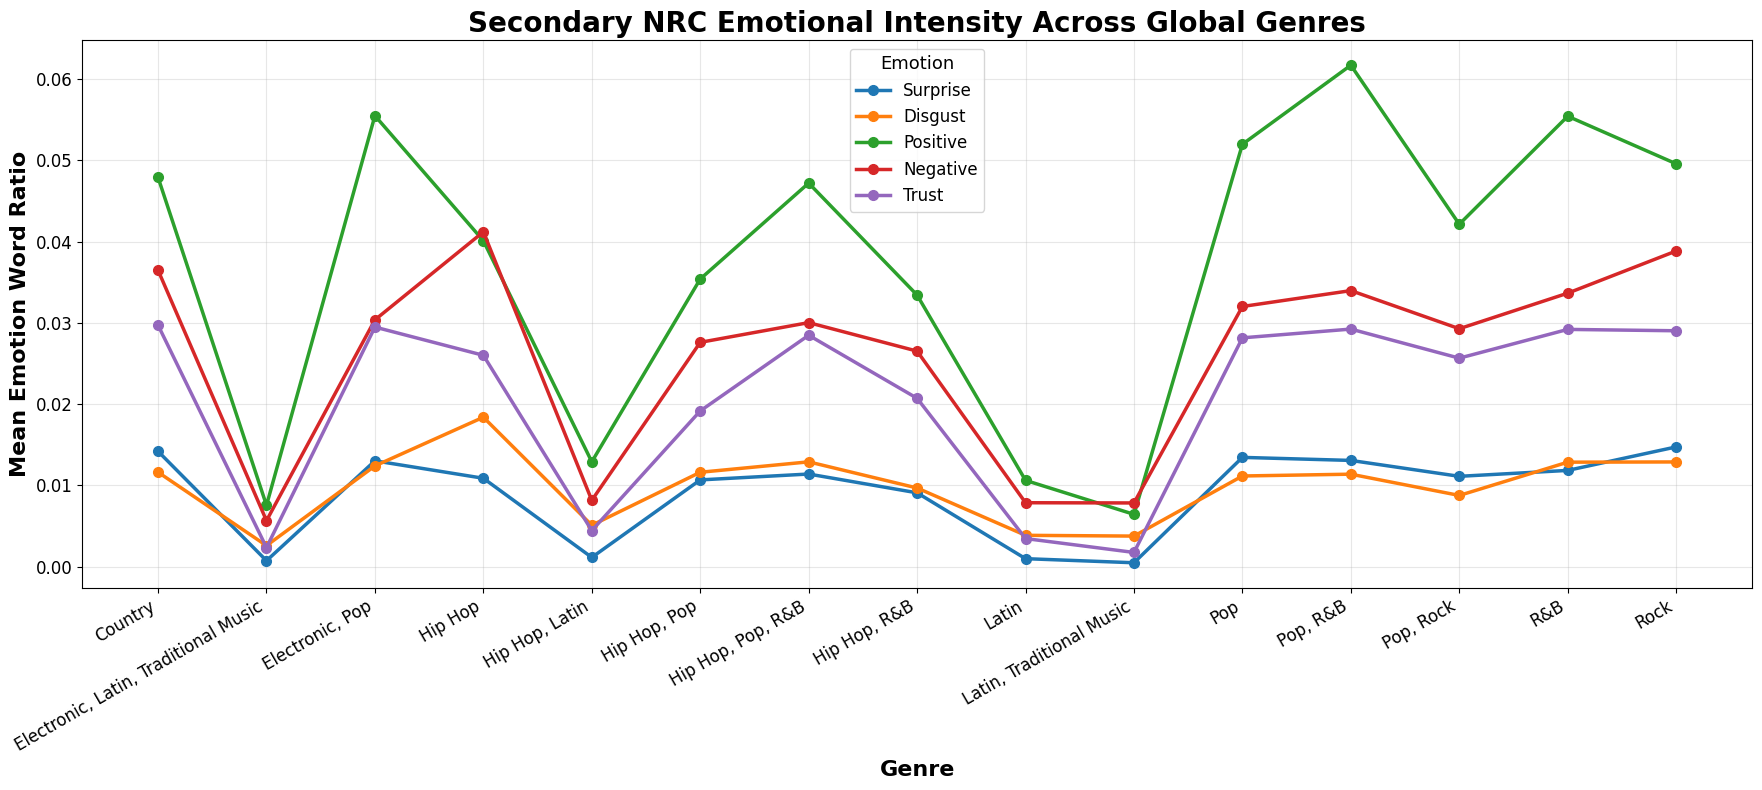

In [6]:
# ----- First emotion plot -----
df_genres_emot = pd.DataFrame({
    'genre': songs['main_genres'],
    'nrc_joy': lyric_stats['nrc_joy'],
    'nrc_sadness': lyric_stats['nrc_sadness'],
    'nrc_anger': lyric_stats['nrc_anger'],
    'nrc_anticipation': lyric_stats['nrc_anticipation'],
    'nrc_fear': lyric_stats['nrc_fear']
})

top_genre_list = df_genres_emot['genre'].value_counts().head(15).index
genre_emot_avg = df_genres_emot[df_genres_emot['genre'].isin(top_genre_list)].groupby('genre').mean()

plt.figure(figsize=(18, 8))
for col in ['nrc_joy', 'nrc_sadness', 'nrc_anger', 'nrc_anticipation', 'nrc_fear']:
    plt.plot(
        genre_emot_avg.index,
        genre_emot_avg[col],
        marker='o',
        linewidth=2.5,
        markersize=7,
        label=col.replace('nrc_', '').capitalize()
    )

plt.title("NRC Emotional Intensity Across Global Genres", fontsize=20, fontweight='bold')
plt.xlabel("Genre", fontsize=16, fontweight='bold')
plt.ylabel("Mean Emotion Word Ratio", fontsize=16, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, title="Emotion", title_fontsize=13, frameon=True)
plt.tight_layout()
plt.show()

# ----- Second identical graph for surprise, disgust, positive, negative -----
df_genres_emot_2 = pd.DataFrame({
    'genre': songs['main_genres'],
    'nrc_surprise': lyric_stats['nrc_surprise'],
    'nrc_disgust': lyric_stats['nrc_disgust'],
    'nrc_positive': lyric_stats['nrc_positive'],
    'nrc_negative': lyric_stats['nrc_negative'], 
    'nrc_trust': lyric_stats['nrc_trust']
})

genre_emot_avg_2 = df_genres_emot_2[df_genres_emot_2['genre'].isin(top_genre_list)].groupby('genre').mean()

plt.figure(figsize=(18, 8))
for col in ['nrc_surprise', 'nrc_disgust', 'nrc_positive', 'nrc_negative', 'nrc_trust']:
    plt.plot(
        genre_emot_avg_2.index,
        genre_emot_avg_2[col],
        marker='o',
        linewidth=2.5,
        markersize=7,
        label=col.replace('nrc_', '').capitalize()
    )

plt.title("Secondary NRC Emotional Intensity Across Global Genres", fontsize=20, fontweight='bold')
plt.xlabel("Genre", fontsize=16, fontweight='bold')
plt.ylabel("Mean Emotion Word Ratio", fontsize=16, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, title="Emotion", title_fontsize=13, frameon=True)
plt.tight_layout()
plt.show()


## 7. Discovering Thematic Clusters via BERTopic
Explore the 32 discovered lyric themes and their top c-TF-IDF keyword signatures.


In [7]:
topic_summary = []
for t_id, data in topic_labels.items():
    topic_summary.append({
        'theme_name': data['name'],
        'song_count': data['count'],
        'top_keywords': ", ".join(data['top_words'])
    })

pd.set_option('display.max_colwidth', None)  # Show full content of 'top_keywords' column
df_topics = pd.DataFrame(topic_summary).sort_values(by='song_count', ascending=False)
df_topics.head(15)


,theme_name,song_count,top_keywords
15,15_por_tú_amor,1184,"por, tú, amor, ti, eu, quiero, más, qué"
20,20_said_ooh ooh_right,1147,"said, ooh ooh, right, girl, need, did, la la, bad"
7,7_tú_por_como,996,"tú, por, como, eu, qué, los, las, quiero"
26,26_night_life_gonna,994,"night, life, gonna, world, away, la la, right, home"
8,8_girl_right_hey,983,"girl, right, hey, need, uh, good, yeah yeah, dance"
30,30_bitch_nigga_fuck,908,"bitch, nigga, fuck, uh, niggas, money, em, yeah yeah"
28,28_need_heart_right,761,"need, heart, right, hold, ooh ooh, won, gonna, away"
10,10_la la_love love_life,556,"la la, love love, life, heart, right, night, eyes, girl"
18,18_away_need_home,425,"away, need, home, ooh ooh, don know, mind, life, night"
6,6_world_gonna_away,404,"world, gonna, away, life, la la, god, won, run"
